# Sandbox notebook

In [2]:
import os
import numpy as np

from IPython.display import Audio

import matplotlib.pyplot as plt

# TODO: Update importing method by defining setup.py and installing the package in editable mode
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from scripts.utils.noise_superposition import noise_superposition

In [3]:
# Define the paths
dataset_path = "../datasets/hatci"
car_names = ['Genesis_SUV']
car_path = os.path.join(dataset_path, car_names[0])

# Initialize the noise superposition object
noise_superposition_obj = noise_superposition(car_path)

In [47]:
# Get the noise for the specified conditions
noise = noise_superposition_obj.get_noise(
    mic_setup='distributed',
    speed=120,
    window=2,
    version=None,
    mics=list(range(8)),
    use_correction_gains=True
)

Audio(noise[:, 0], rate=noise_superposition_obj.fs)

In [48]:
# Get the ventilation noise for the specified conditions
ventilation = noise_superposition_obj.get_ventilation(
    mic_setup='distributed',
    level=3,
    window=2,
    version=None,
    mics=list(range(8)),
    use_correction_gains=True
)

Audio(ventilation[:, 0], rate=noise_superposition_obj.fs)

In [49]:
# Match the audio duration based on the first item in the audio list
audio_list = [noise, ventilation]
matched_audio_list = noise_superposition_obj.match_duration(audio_list=audio_list, fs=noise_superposition_obj.fs)

In [50]:
# Superimpose the noise and ventilation recordings
mixed_noise = matched_audio_list[0] + matched_audio_list[1]
Audio(mixed_noise[:, 0], rate=noise_superposition_obj.fs)

In [8]:
# Load noise example
noise_recordings = noise_superposition_obj.noise_recordings
condition = noise_recordings["distributed"][4]

noise, fs_noise = noise_superposition_obj.load_noise(
    mic_setup="distributed",
    condition=condition,
    mic_range=list(range(8))
)

# Load ventilation example
ventilation_recordings = noise_superposition_obj.ventilation_recordings
condition = ventilation_recordings["distributed"][0]

ventilation, fs_ventilation = noise_superposition_obj.load_ventilation(
    mic_setup="distributed",
    condition=condition,
    mic_range=list(range(8))
)

### STFT

In [51]:
import os
import numpy as np
import soundfile as sf
import scipy.signal as signal
from scipy.signal import resample_poly
import matplotlib.pyplot as plt

In [52]:
def extract_spectrogram(
    x,
    fs,
    window_duration=0.025,
    hop_duration=0.010,
    n_fft=512,
    window="hann",
    spectrogram_type="db",
    eps=1e-12
):
    if x.ndim != 1:
        raise ValueError("extract_spectrogram expects a single-channel signal.")
    
    nperseg = int(round(window_duration * fs))
    hop = int(round(hop_duration * fs))
    noverlap = nperseg - hop

    if n_fft < nperseg:
        raise ValueError("n_fft must be greater than or equal to window length.")
    
    freqs, times, Zxx = signal.stft(
        x,
        fs=fs,
        window=window,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=n_fft,
        boundary=None,
        padded=False
    )

    magnitude = np.abs(Zxx)

    if spectrogram_type == "magnitude":
        spec = magnitude
    elif spectrogram_type == "power":
        spec = magnitude**2
    elif spectrogram_type == "db":
        spec = 20 * np.log10(magnitude + eps)
    else:
        raise ValueError(
            "spectrogram_type must be one of: 'magnitude', 'power', 'db'."
        )
    
    params = {
        "fs": fs,
        "window_duration": window_duration,
        "hop_duration": hop_duration,
        "nperseg": nperseg,
        "hop": hop,
        "noverlap": noverlap,
        "n_fft": n_fft,
        "window": window,
        "spectrogram_type": spectrogram_type,
        "frequency_resolution_fft_grid": fs / n_fft,
        "num_frequency_bins": len(freqs),
        "num_time_frames": len(times)
    }

    return spec, freqs, times, Zxx, params

def plot_spectrogram(
    spec,
    freqs,
    times,
    colorbar_label=None,
    max_freq=None,
    dynamic_range_db=80
):
    spec_plot = spec.copy()

    # if max_freq is not None:
    #     freq_mask = freqs <= max_freq
    #     freqs = freqs[freq_mask]
    #     spec_plot = spec_plot[freq_mask, :]

    # vmax = np.max(spec_plot)
    # vmin = vmax - dynamic_range_db

    plt.figure(figsize=(10, 4))
    plt.pcolormesh(times, freqs, spec_plot, shading="gouraud") # vmin=vmin, vmax=vmax
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.colorbar(label=colorbar_label)
    plt.tight_layout()
    plt.show()

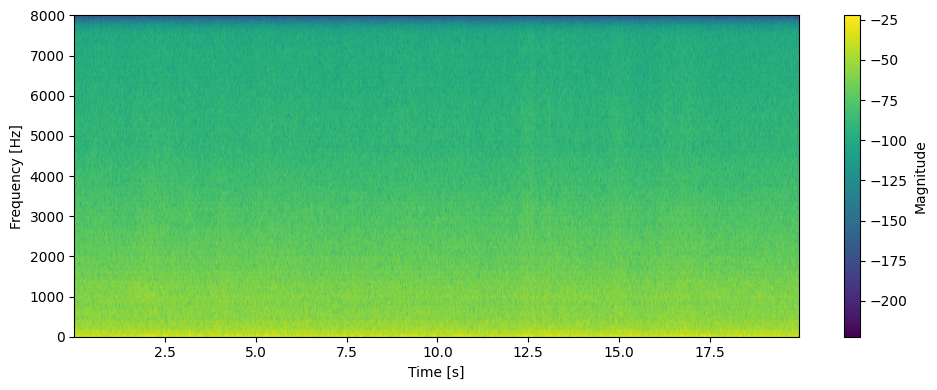

In [55]:
fs = noise_superposition_obj.fs
x = mixed_noise[:, 1]
spec_db, freqs, times, Zxx, params = extract_spectrogram(
    x=x,
    fs=fs,
    window_duration=0.020,
    hop_duration=0.010,
    n_fft=512,
    window="hann",
    spectrogram_type="db"
)

plot_spectrogram(
    spec_db,
    freqs,
    times,
    colorbar_label="Magnitude"
)